# Block 1
## Import und Einlesen von Dateien. Umwandlung leerer Werte in NaN + Überprüfung

In [5]:
import pandas as pd
import numpy as np
import openpyxl

# === 0) Spalten, die WEDER im Datentyp NOCH in den Werten verändert werden dürfen ===
LOCKED = {
    "calls":    ["Id", "CONTACTID"],
    "contacts": ["Id"],
    "deals":    ["Id", "Contact Name"],
    # spend: aktuell gibt es noch keine "gesperrten" Spalten
    # (wir ergänzen sie bei Bedarf)
}

# === 1) Dateien einlesen (ID-Spalten werden explizit als TEXT eingelesen) ===
def read_excel_force_text(path, text_cols):
    converters = {c: (lambda x: "" if pd.isna(x) else str(x).strip()) for c in text_cols}
    return pd.read_excel(path, engine="openpyxl", converters=converters)

calls = read_excel_force_text(
    r'C:\Users\Acer\Projekt\RawData\Calls.xlsx',
    text_cols=["Id", "CONTACTID"]
)
contacts = read_excel_force_text(
    r'C:\Users\Acer\Projekt\RawData\Contacts.xlsx',
    text_cols=["Id"]
)
deals = read_excel_force_text(
    r'C:\Users\Acer\Projekt\RawData\Deals.xlsx',
    text_cols=["Id", "Contact Name"]
)

# spend enthält keine ID-Schlüsselspalten — daher normales Einlesen
spend = pd.read_excel(r'C:\Users\Acer\Projekt\RawData\Spend.xlsx', engine='openpyxl')

# === 2) "Schnappschuss" der LOCKED-Spalten VOR der Bereinigung speichern ===
_before_locked = {}
for name, df in [("calls", calls), ("contacts", contacts), ("spend", spend), ("deals", deals)]:
    cols = [c for c in LOCKED.get(name, []) if c in df.columns]
    _before_locked[name] = {c: df[c].copy(deep=True) for c in cols}

# === 3) Leere Strings, N/A, None usw. in NA umwandeln —
#       NUR in Spalten, die NICHT gesperrt sind ===
MISSING_TOKENS = ["", " ", "N/A", "null", "None"]

def replace_missing_except_locked(df: pd.DataFrame, locked_cols: list[str]) -> pd.DataFrame:
    locked = set(locked_cols)
    for col in df.columns:
        if col in locked:
            continue
        df[col] = df[col].replace(MISSING_TOKENS, pd.NA)
    return df

calls    = replace_missing_except_locked(calls,    LOCKED["calls"])
contacts = replace_missing_except_locked(contacts, LOCKED["contacts"])
spend    = replace_missing_except_locked(spend,    LOCKED.get("spend", []))
deals    = replace_missing_except_locked(deals,    LOCKED["deals"])

# (optional, aber nützlich für BI): Unendlichkeiten -> NA
for df in [calls, contacts, spend, deals]:
    df.replace([np.inf, -np.inf], pd.NA, inplace=True)

# === 4) STRIKTE Prüfung: LOCKED-Spalten dürfen sich weder
#       in den Werten noch im Datentyp geändert haben ===
def assert_locked_unchanged(name: str, df: pd.DataFrame):
    for col, before_series in _before_locked.get(name, {}).items():
        after_series = df[col]

        if before_series.dtype != after_series.dtype:
            raise TypeError(
                f"[{name}] Der Datentyp in der Spalte '{col}' hat sich geändert: "
                f"{before_series.dtype} -> {after_series.dtype}"
            )

        if not before_series.equals(after_series):
            raise ValueError(
                f"[{name}] Die Werte in der Spalte '{col}' haben sich geändert. "
                f"Diese Spalte ist als LOCKED markiert und darf nicht verändert werden."
            )

for name, df in [("calls", calls), ("contacts", contacts), ("spend", spend), ("deals", deals)]:
    assert_locked_unchanged(name, df)

# === 5) Prüfung ===
print("=== CALLS NaN ===")
print(calls.isna().sum())
print("=== CONTACTS NaN ===")
print(contacts.isna().sum())
print("=== SPEND NaN ===")
print(spend.isna().sum())
print("=== DEALS NaN ===")
print(deals.isna().sum())

=== CALLS NaN ===
Id                                0
Call Start Time                   0
Call Owner Name                   0
CONTACTID                      3933
Call Type                         0
Call Duration (in seconds)       83
Call Status                       0
Dialled Number                95874
Outgoing Call Status           8999
Scheduled in CRM               8999
Tag                           95874
dtype: int64
=== CONTACTS NaN ===
Id                    0
Contact Owner Name    0
Created Time          0
Modified Time         0
dtype: int64
=== SPEND NaN ===
Date              0
Source            0
Campaign       5994
Impressions       0
Spend             0
Clicks            0
AdGroup        6828
Ad             6828
dtype: int64
=== DEALS NaN ===
Id                         2
Deal Owner Name           31
Closing Date            6950
Quality                 2255
Stage                      2
Lost Reason             5471
Page                       2
Campaign                5528
SL

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Block 2

## Funktion für Euro-Werte + Überprüfung

In [7]:
import re

def euro_to_float_safe(series: pd.Series) -> pd.Series:
    """
    Wandelt Geldbeträge sicher in float um:
    - '€ 2.900,00' -> 2900.0
    - '2900,00'    -> 2900.0
    - '2900.00'    -> 2900.0
    - numerische Werte bleiben unverändert
    - NaN bleibt NaN
    """

    s = series.copy()

    # ursprüngliche NaN-Werte speichern
    mask_na = s.isna()

    # alles in Strings umwandeln, um die Bereinigung zu erleichtern
    s = s.astype(str)

    # Währungssymbol und Leerzeichen entfernen
    s = s.str.replace("€", "", regex=False)
    s = s.str.replace(" ", "", regex=False)

    # europäisches Zahlenformat erkennen: 1.234,56
    euro_mask = s.str.contains(r"\d+\.\d+,\d+", regex=True)

    s.loc[euro_mask] = (
        s.loc[euro_mask]
        .str.replace(".", "", regex=False)   # Tausenderpunkt entfernen
        .str.replace(",", ".", regex=False)  # Dezimalkomma in Punkt umwandeln
    )

    # Format mit Komma als Dezimaltrennzeichen erkennen
    comma_decimal = s.str.contains(r"\d+,\d+$", regex=True)
    s.loc[comma_decimal] = s.loc[comma_decimal].str.replace(",", ".", regex=False)

    # finale Umwandlung in numerischen Typ
    s = pd.to_numeric(s, errors="coerce")

    # ursprüngliche NaN-Werte wiederherstellen
    s.loc[mask_na] = np.nan

    return s

In [8]:
# Kontrollwerte VOR der Umwandlung speichern
_before_amounts = deals[['Initial Amount Paid', 'Offer Total Amount']].copy()

# Euro-Beträge sicher in float konvertieren
deals['Initial Amount Paid'] = euro_to_float_safe(deals['Initial Amount Paid'])
deals['Offer Total Amount'] = euro_to_float_safe(deals['Offer Total Amount'])

In [9]:
# Überprüfung der Ergebnisse nach der Umwandlung
for col in ['Initial Amount Paid', 'Offer Total Amount']:
    print(f"\n=== {col} ===")

    # Anzahl der NaN-Werte vor und nach der Konvertierung
    print("NaN vorher :", _before_amounts[col].isna().sum())
    print("NaN nachher:", deals[col].isna().sum())

    # Summenvergleich vor und nach der Konvertierung
    print("Summe vorher :", pd.to_numeric(_before_amounts[col], errors='coerce').sum())
    print("Summe nachher:", deals[col].sum())


=== Initial Amount Paid ===
NaN до : 17430
NaN после: 17431
Сумма до : 3900112.0
Сумма после: 3956112.0

=== Offer Total Amount ===
NaN до : 17410
NaN после: 17410
Сумма до : 29764313.0
Сумма после: 29833711.0


In [12]:
bad_rows = deals[
    deals['Initial Amount Paid'].isna() &
    _before_amounts['Initial Amount Paid'].notna()
][['Initial Amount Paid']]

print(bad_rows)

      Initial Amount Paid
1121                  NaN


# Block 3
## Datentypen umwandeln + Überprüfung

In [13]:
# ===== CALLS =====
# WICHTIG: calls['Id'] und calls['CONTACTID'] NICHT verändern (LOCKED)

if 'Call Owner Name' in calls.columns:
    calls['Call Owner Name'] = calls['Call Owner Name'].astype('string')

if 'Call Duration (in seconds)' in calls.columns:
    calls['Call Duration (in seconds)'] = pd.to_numeric(
        calls['Call Duration (in seconds)'], errors='coerce'
    ).astype('Int64')

cat_cols_calls = ['Call Type', 'Call Status', 'Outgoing Call Status', 'Scheduled in CRM']
for col in cat_cols_calls:
    if col in calls.columns:
        calls[col] = calls[col].astype('category')


# ===== CONTACTS =====
# WICHTIG: contacts['Id'] NICHT verändern (LOCKED)

if 'Contact Owner Name' in contacts.columns:
    contacts['Contact Owner Name'] = contacts['Contact Owner Name'].astype('string')


# ===== SPEND =====
# In spend gibt es keine LOCKED-Spalten,
# daher können die Datentypen frei angepasst werden

if 'Impressions' in spend.columns:
    spend['Impressions'] = pd.to_numeric(spend['Impressions'], errors='coerce').astype('Int64')

if 'Clicks' in spend.columns:
    spend['Clicks'] = pd.to_numeric(spend['Clicks'], errors='coerce').astype('Int64')

if 'Spend' in spend.columns:
    spend['Spend'] = pd.to_numeric(spend['Spend'], errors='coerce').astype('float64')

if 'Source' in spend.columns:
    spend['Source'] = spend['Source'].astype('category')


# ===== DEALS =====
# WICHTIG: deals['Id'] und deals['Contact Name'] NICHT verändern (LOCKED)

if 'Deal Owner Name' in deals.columns:
    deals['Deal Owner Name'] = deals['Deal Owner Name'].astype('string')

if 'City' in deals.columns:
    deals['City'] = deals['City'].astype('string')

# !!! ENTFERNT: Umwandlung von deals['Contact Name'] in eine Zahl —
# das würde die Daten beschädigen.
# deals['Contact Name'] muss unverändert bleiben (LOCKED).

cat_cols_deals = ['Quality', 'Stage', 'Source', 'Payment Type', 'Product', 'Education Type']
for col in cat_cols_deals:
    if col in deals.columns:
        deals[col] = deals[col].astype('category')

if 'Course duration' in deals.columns:
    deals['Course duration'] = pd.to_numeric(deals['Course duration'], errors='coerce').astype('Int64')

if 'Months of study' in deals.columns:
    deals['Months of study'] = pd.to_numeric(deals['Months of study'], errors='coerce').astype('Int64')


# === Erneute STRIKTE Prüfung nach der Typumwandlung ===
for name, df in [("calls", calls), ("contacts", contacts), ("spend", spend), ("deals", deals)]:
    assert_locked_unchanged(name, df)


# ===== Prüfung der Datentypen =====
print("=== CALLS dtypes ===")
print(calls.dtypes)
print("=== CONTACTS dtypes ===")
print(contacts.dtypes)
print("=== SPEND dtypes ===")
print(spend.dtypes)
print("=== DEALS dtypes ===")
print(deals.dtypes)

=== CALLS dtypes ===
Id                                    object
Call Start Time                       object
Call Owner Name               string[python]
CONTACTID                             object
Call Type                           category
Call Duration (in seconds)             Int64
Call Status                         category
Dialled Number                       float64
Outgoing Call Status                category
Scheduled in CRM                    category
Tag                                  float64
dtype: object
=== CONTACTS dtypes ===
Id                            object
Contact Owner Name    string[python]
Created Time                  object
Modified Time                 object
dtype: object
=== SPEND dtypes ===
Date           datetime64[ns]
Source               category
Campaign               object
Impressions             Int64
Spend                 float64
Clicks                  Int64
AdGroup                object
Ad                     object
dtype: object
=== DEALS

# Block 4
## Datumsumwandlung + Überprüfung

In [14]:
# ===== CALLS =====
if 'Call Start Time' in calls.columns:
    calls['Call Start Time'] = pd.to_datetime(
        calls['Call Start Time'],
        errors='coerce',
        dayfirst=True
    )

# ===== CONTACTS =====
for col in ['Created Time', 'Modified Time']:
    if col in contacts.columns:
        contacts[col] = pd.to_datetime(
            contacts[col],
            errors='coerce',
            dayfirst=True
        )

# ===== DEALS =====
date_cols_deals = ['Closing Date', 'Created Time', 'SLA']
for col in date_cols_deals:
    if col in deals.columns:
        deals[col] = pd.to_datetime(
            deals[col],
            errors='coerce',
            dayfirst=True
        )

# ===== Prüfung der Datentypen =====
print("=== CALLS datetime-Spalten ===")
print(calls.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).dtypes)

print("=== CONTACTS datetime-Spalten ===")
print(contacts.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).dtypes)

print("=== DEALS datetime-Spalten ===")
print(deals.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).dtypes)

# ===== Für den Export im Format YYYY-MM-DD
#       (ohne dass NaT in den String 'NaT' umgewandelt wird) =====
deals_export = deals.copy()
for col in date_cols_deals:
    if col in deals_export.columns:
        # .dt.strftime wandelt NaT in NaN um
        # (das ist für BI hilfreich),
        # aber der Datentyp wird dabei zu object/string —
        # das ist für die Export-Version in Ordnung
        deals_export[col] = deals_export[col].dt.strftime('%Y-%m-%d')

=== CALLS datetime cols ===
Call Start Time    datetime64[ns]
dtype: object
=== CONTACTS datetime cols ===
Created Time     datetime64[ns]
Modified Time    datetime64[ns]
dtype: object
=== DEALS datetime cols ===
Closing Date    datetime64[ns]
SLA             datetime64[ns]
Created Time    datetime64[ns]
dtype: object


In [15]:
def check_suspicious_dates(df, df_name, date_cols, min_date="2010-01-01", max_date=None, sample_n=5):
    """
    Prüft Datumswerte auf Auffälligkeiten:
    - früher als min_date
    - später als max_date (standardmäßig: heute)
    Gibt eine Zusammenfassung und einige Beispielzeilen aus.
    Es werden keine Daten verändert.
    """
    min_date = pd.Timestamp(min_date)
    max_date = pd.Timestamp.today().normalize() if max_date is None else pd.Timestamp(max_date)

    print(f"\n===== Prüfung auffälliger Datumswerte: {df_name} =====")
    print(f"Erlaubter Bereich: [{min_date.date()} .. {max_date.date()}]")

    for col in date_cols:
        if col not in df.columns:
            print(f"  - {col}: Spalte nicht gefunden (übersprungen)")
            continue

        s = df[col]

        # Falls die Spalte wider Erwarten noch kein datetime-Typ ist,
        # wird sie vorsichtshalber in eine temporäre Kopie umgewandelt
        if not pd.api.types.is_datetime64_any_dtype(s):
            s = pd.to_datetime(s, errors="coerce", dayfirst=True)

        total = len(s)
        na = s.isna().sum()
        too_early = (s < min_date).sum()
        too_late = (s > max_date).sum()

        print(f"\n  [{col}]")
        print(f"    Gesamtzahl: {total:,}")
        print(f"    NaT       : {na:,}")
        print(f"    < {min_date.date()}: {too_early:,}")
        print(f"    > {max_date.date()}: {too_late:,}")

        # Beispiele für auffällige Werte anzeigen
        bad_idx = df.index[(df[col] < min_date) | (df[col] > max_date)]
        if len(bad_idx) > 0:
            print(f"    Beispiele (maximal {sample_n}):")
            ex = df.loc[bad_idx[:sample_n], [col]].copy()
            print(ex)
        else:
            print("    Beispiele: keine ✅")


# === Anwendung auf die Datensätze ===
check_suspicious_dates(calls, "calls", ["Call Start Time"], min_date="2010-01-01")
check_suspicious_dates(contacts, "contacts", ["Created Time", "Modified Time"], min_date="2010-01-01")
check_suspicious_dates(deals, "deals", ["Closing Date", "Created Time", "SLA"], min_date="2010-01-01")


===== Suspicious dates check: calls =====
Allowed range: [2010-01-01 .. 2026-02-06]

  [Call Start Time]
    total: 95,874
    NaT : 0
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅

===== Suspicious dates check: contacts =====
Allowed range: [2010-01-01 .. 2026-02-06]

  [Created Time]
    total: 18,548
    NaT : 0
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅

  [Modified Time]
    total: 18,548
    NaT : 0
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅

===== Suspicious dates check: deals =====
Allowed range: [2010-01-01 .. 2026-02-06]

  [Closing Date]
    total: 21,595
    NaT : 6,950
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅

  [Created Time]
    total: 21,595
    NaT : 2
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅

  [SLA]
    total: 21,595
    NaT : 21,595
    < 2010-01-01: 0
    > 2026-02-06: 0
    examples: none ✅


# Block 5
## Entfernen überflüssiger Spalten und Duplikate + Überprüfung

In [16]:
# ===== SCHRITT: ÜBERFLÜSSIGES ENTFERNEN (SPALTEN, LEERE ZEILEN, VOLLSTÄNDIGE DUBLETTEN) =====
# WICHTIG: Dieser Schritt ENTFERNT ZEILEN. Deshalb verwenden wir eine Prüfung,
# die das Löschen von Zeilen erlaubt, aber garantiert, dass sich die Werte
# in den LOCKED-Spalten der verbleibenden Datensätze nicht verändert haben.

import pandas as pd

# --- 0) Prüfung der LOCKED-Spalten unter Zulassung gelöschter Zeilen ---
def assert_locked_unchanged_allow_row_drop(name: str, df: pd.DataFrame):
    """
    Erlaubt das Löschen von Zeilen, verbietet aber:
    - Änderungen des Datentyps in LOCKED-Spalten
    - Änderungen der Werte in LOCKED-Spalten bei den verbleibenden Indizes
    Setzt voraus, dass _before_locked existiert
    (Schnappschuss der LOCKED-Spalten VOR der Bereinigung).
    """
    for col, before_series in _before_locked.get(name, {}).items():
        if col not in df.columns:
            raise KeyError(f"[{name}] Die LOCKED-Spalte '{col}' fehlt im Datensatz.")

        after_series = df[col]

        # Der Datentyp darf sich nicht ändern
        if before_series.dtype != after_series.dtype:
            raise TypeError(
                f"[{name}] Der Datentyp in der Spalte '{col}' hat sich geändert: "
                f"{before_series.dtype} -> {after_series.dtype}"
            )

        # Die Werte an den verbleibenden Indizes dürfen sich nicht ändern
        before_aligned = before_series.loc[df.index]
        if not before_aligned.equals(after_series):
            diff_mask = before_aligned != after_series
            diff_idx = df.index[diff_mask]
            raise ValueError(
                f"[{name}] Die Werte in der LOCKED-Spalte '{col}' "
                f"haben sich an folgenden Indizes geändert (erste 10): {list(diff_idx[:10])}"
            )


# --- 1) Überflüssige Spalten entfernen ---
calls = calls.drop(columns=['Dialled Number', 'Tag'], errors='ignore')
deals = deals.drop(columns=['Term'], errors='ignore')
spend = spend.drop(columns=['AdGroup', 'Ad'], errors='ignore')


# --- 2) Vollständig leere Zeilen entfernen (100 % sicher) ---
calls = calls.dropna(how='all')
contacts = contacts.dropna(how='all')
spend = spend.dropna(how='all')
deals = deals.dropna(how='all')


# --- 3) NUR vollständige Dubletten entfernen, mit Protokollausgabe ---
def drop_full_duplicates_safe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    before = len(df)
    dup_count = df.duplicated().sum()

    if dup_count > 0:
        print(f"[{name}] Vollständige Dubletten gefunden: {dup_count}")
        df = df.drop_duplicates()
    else:
        print(f"[{name}] Keine vollständigen Dubletten gefunden")

    after = len(df)
    print(f"[{name}] Zeilen vorher: {before}, nachher: {after}")
    return df

calls    = drop_full_duplicates_safe(calls, "calls")
contacts = drop_full_duplicates_safe(contacts, "contacts")
spend    = drop_full_duplicates_safe(spend, "spend")
deals    = drop_full_duplicates_safe(deals, "deals")


# --- 4) Prüfung: LOCKED-Spalten haben sich nicht verändert
#         (unter Berücksichtigung gelöschter Zeilen) ---
for name, df in [("calls", calls), ("contacts", contacts), ("spend", spend), ("deals", deals)]:
    assert_locked_unchanged_allow_row_drop(name, df)


# --- 5) Abschlussprüfung ---
print("=== CALLS Dubletten & leere Zeilen ===",
      calls.duplicated().sum(),
      calls.isna().all(axis=1).sum())

print("=== CONTACTS Dubletten & leere Zeilen ===",
      contacts.duplicated().sum(),
      contacts.isna().all(axis=1).sum())

print("=== SPEND Dubletten & leere Zeilen ===",
      spend.duplicated().sum(),
      spend.isna().all(axis=1).sum())

print("=== DEALS Dubletten & leere Zeilen ===",
      deals.duplicated().sum(),
      deals.isna().all(axis=1).sum())

[calls] no full duplicates
[calls] rows before: 95874, after: 95874
[contacts] no full duplicates
[contacts] rows before: 18548, after: 18548
[spend] full duplicates found: 1167
[spend] rows before: 20779, after: 19612
[deals] no full duplicates
[deals] rows before: 21594, after: 21594
=== CALLS duplicates & empty === 0 0
=== CONTACTS duplicates & empty === 0 0
=== SPEND duplicates & empty === 0 0
=== DEALS duplicates & empty === 0 0


# Block 6
## Prüfung der Datenvollständigkeit + Spalten < 80 % + Überprüfung

In [17]:
def percent_filled(df: pd.DataFrame) -> pd.Series:
    """
    Berechnet den prozentualen Füllgrad der Spalten.
    Funktioniert auch sicher mit leeren DataFrames.
    """
    total_rows = len(df)

    if total_rows == 0:
        return pd.Series(dtype="float64")

    return (df.notna().sum() / total_rows * 100).round(2)


def low_fill_columns(df: pd.DataFrame, threshold: float = 80) -> pd.Series:
    """
    Gibt Spalten zurück, deren Füllgrad unter dem definierten Schwellenwert (%) liegt.
    """
    pct = percent_filled(df)
    return pct[pct < threshold].sort_values()

In [18]:
print("=== CALLS Füllgrad (%) ===")
calls_fill = percent_filled(calls)
print(calls_fill)
print("Spalten <80%:")
print(low_fill_columns(calls))

print("\n=== CONTACTS Füllgrad (%) ===")
contacts_fill = percent_filled(contacts)
print(contacts_fill)
print("Spalten <80%:")
print(low_fill_columns(contacts))

print("\n=== SPEND Füllgrad (%) ===")
spend_fill = percent_filled(spend)
print(spend_fill)
print("Spalten <80%:")
print(low_fill_columns(spend))

print("\n=== DEALS Füllgrad (%) ===")
deals_fill = percent_filled(deals)
print(deals_fill)
print("Spalten <80%:")
print(low_fill_columns(deals))

=== CALLS % заполненности ===
Id                            100.00
Call Start Time               100.00
Call Owner Name               100.00
CONTACTID                      95.90
Call Type                     100.00
Call Duration (in seconds)     99.91
Call Status                   100.00
Outgoing Call Status           90.61
Scheduled in CRM               90.61
dtype: float64
Столбцы <80%:
Series([], dtype: float64)

=== CONTACTS % заполненности ===
Id                    100.0
Contact Owner Name    100.0
Created Time          100.0
Modified Time         100.0
dtype: float64
Столбцы <80%:
Series([], dtype: float64)

=== SPEND % заполненности ===
Date           100.00
Source         100.00
Campaign        74.11
Impressions    100.00
Spend          100.00
Clicks         100.00
dtype: float64
Столбцы <80%:
Campaign    74.11
dtype: float64

=== DEALS % заполненности ===
Id                     100.00
Deal Owner Name         99.86
Closing Date            67.82
Quality                 89.56
Sta

In [19]:
deals.describe()

,Closing Date,SLA,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,14645,0,21593,3587.0,839.0,4164.000000,4185.000000
mean,2024-01-27 16:37:43.489245440,NaT,2024-01-27 01:44:13.334877184,10.198495,5.448153,950.074928,7128.724253
min,2022-10-11 00:00:00,NaT,2023-07-03 17:03:00,6.0,0.0,0.000000,0.000000
25%,2023-11-11 00:00:00,NaT,2023-11-18 13:33:00,11.0,3.0,300.000000,3000.000000
50%,2024-02-07 00:00:00,NaT,2024-02-05 07:46:00,11.0,5.0,1000.000000,11000.000000
75%,2024-04-17 00:00:00,NaT,2024-04-13 19:19:00,11.0,8.0,1000.000000,11000.000000
max,2024-12-11 00:00:00,NaT,2024-06-21 15:30:00,11.0,11.0,11500.000000,11500.000000
std,NaN,NaN,NaN,1.834681,2.917623,1422.323165,4636.020784


In [20]:
spend.describe()

,Date,Impressions,Spend,Clicks
count,19612,19612.0,19612.000000,19612.0
mean,2024-01-10 17:34:40.114215936,2604.472976,7.624056,25.415817
min,2023-07-03 00:00:00,0.0,0.000000,0.0
25%,2023-10-09 00:00:00,1.0,0.000000,0.0
50%,2024-01-20 00:00:00,89.0,0.790000,2.0
75%,2024-04-12 00:00:00,776.0,6.300000,13.0
max,2024-06-21 00:00:00,431445.0,774.000000,2415.0
std,NaN,11761.882407,27.485468,87.538868


# Block 8
## Verteilungen für Spalten mit < 80 % Füllgrad analysieren

In [ ]:
# Bestimmung von "schwach gefüllten" Spalten

# 1. Prozentsatz der ausgefüllten Werte in jeder Spalte berechnen.
# 2. Nur Spalten auswählen, deren Füllgrad unter dem definierten
#    Schwellenwert (z. B. 80 %) liegt.
# 3. Diese Spalten sind besonders interessant, da sie viele fehlende
#    Werte enthalten können und daher visuell analysiert werden sollten.

Колонки с заполненностью < 80%:
Campaign    74.11
dtype: float64

=== Categorical Variables ===
['Campaign']

=== Numerical Variables ===
[]


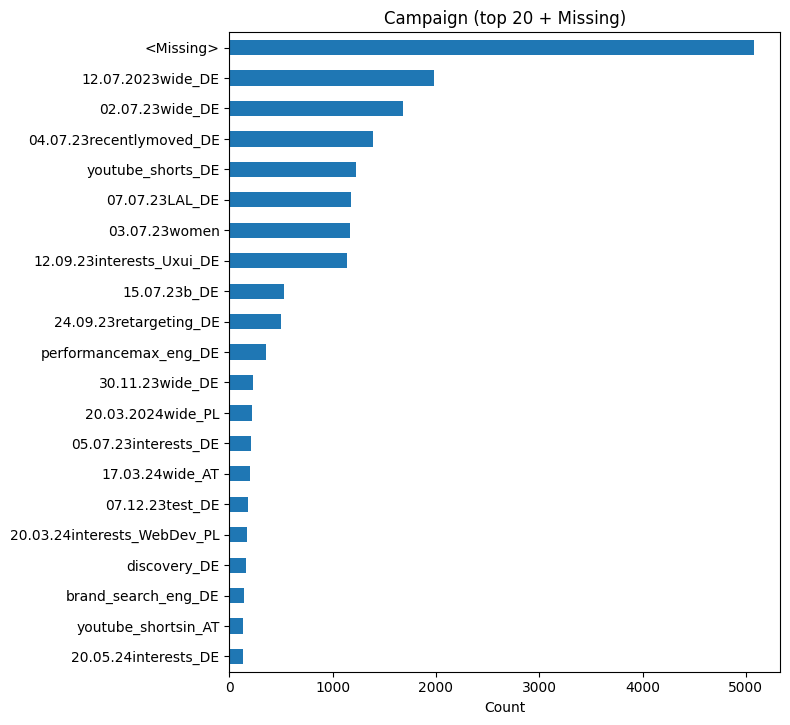

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_low_fill_simple(df: pd.DataFrame, threshold: float = 80, top_n_categories: int = 20):
    """
    Visualisiert Spalten mit einem Füllgrad unter threshold%.
    - Numerische Spalten: Histogramm + Boxplot
    - Kategoriale Spalten: Balkendiagramm der Top-N-Kategorien
      (+ separate Zeile '<Missing>')
    Die Daten selbst werden dabei nicht verändert.
    """

    if df is None or not isinstance(df, pd.DataFrame):
        raise TypeError("df muss ein pandas DataFrame sein")

    if len(df) == 0:
        print("Der DataFrame ist leer — keine Visualisierung durchgeführt.")
        return

    # Spalten mit Füllgrad < threshold%
    fill_pct = (df.notna().sum() / len(df) * 100).round(2)
    low_fill_cols = fill_pct[fill_pct < threshold].index.tolist()

    if not low_fill_cols:
        print(f"Es gibt keine Spalten mit einem Füllgrad unter {threshold}%.")
        return

    # Aufteilen in numerische und kategoriale Spalten
    low_df = df[low_fill_cols]
    num_cols = low_df.select_dtypes(include=[np.number]).columns.tolist()

    # Kategoriale Spalten: category, object, string
    cat_cols = low_df.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

    print(f"Spalten mit Füllgrad < {threshold}%:")
    print(fill_pct.loc[low_fill_cols].sort_values())

    print("\n=== Kategoriale Variablen ===")
    print(cat_cols)
    print("\n=== Numerische Variablen ===")
    print(num_cols)

    # --- Numerische Spalten: Histogramm + Boxplot ---
    for col in num_cols:
        s = df[col].dropna()
        if s.empty:
            print(f"\n[{col}] enthält nur fehlende Werte — Diagramme werden übersprungen.")
            continue

        fig = plt.figure(figsize=(10, 4))

        ax1 = fig.add_subplot(1, 2, 1)
        ax1.hist(s, bins=20)
        ax1.set_title(f"{col} (Histogramm)")

        ax2 = fig.add_subplot(1, 2, 2)
        ax2.boxplot(s, vert=False)
        ax2.set_title(f"{col} (Boxplot)")

        plt.tight_layout()
        plt.show()

    # --- Kategoriale Spalten: Top-N-Balkendiagramm + Missing ---
    for col in cat_cols:
        s = df[col]

        # Top-Kategorien zählen + Missing separat erfassen
        vc = s.value_counts(dropna=True)
        missing = s.isna().sum()

        # Falls es zu viele eindeutige Werte gibt, nur die Top-N anzeigen
        vc_top = vc.head(top_n_categories)

        # Missing als eigene Kategorie hinzufügen (falls vorhanden)
        if missing > 0:
            vc_top = pd.concat([vc_top, pd.Series({"<Missing>": missing})])

        if vc_top.empty:
            print(f"\n[{col}] keine Daten zur Darstellung vorhanden.")
            continue

        plt.figure(figsize=(8, max(4, 0.35 * len(vc_top))))
        vc_top.sort_values().plot(kind="barh")
        plt.title(f"{col} (Top {top_n_categories} + Missing)")
        plt.xlabel("Anzahl")
        plt.tight_layout()
        plt.show()


# Beispiel: für spend
visualize_low_fill_simple(spend, threshold=80, top_n_categories=20)

In [22]:
def summary_fill(df):
    """
    Erstellt eine Übersicht über:
    - Prozentsatz der ausgefüllten Werte pro Spalte
    - Prozentsatz der Werte 'Unknown'
    """
    summary = pd.DataFrame({
        'filled_%': df.notna().mean() * 100,
        'unknown_%': (df == 'Unknown').mean() * 100
    })
    return summary


print("\n=== SPEND: % ausgefüllte Werte und % 'Unknown' ===")
print(summary_fill(spend))


=== SPEND: % заполненных значений и % Unknown ===
               filled_%  unknown_%
Date         100.000000        0.0
Source       100.000000        0.0
Campaign      74.112788        0.0
Impressions  100.000000        0.0
Spend        100.000000        0.0
Clicks       100.000000        0.0


In [23]:
# Verteilung der Kampagnen analysieren
campaign_dist = (
    spend['Campaign']
    .fillna('<Missing>')   # Fehlende Werte als eigene Kategorie markieren
    .value_counts()        # Anzahl der Vorkommen pro Kategorie zählen
    .to_frame('count')     # In DataFrame mit Spaltenname 'count' umwandeln
)

# Prozentanteil jeder Kategorie berechnen
campaign_dist['percent'] = (
    campaign_dist['count'] / campaign_dist['count'].sum() * 100
).round(2)

# Ergebnis ausgeben
print(campaign_dist)

                             count  percent
Campaign                                   
<Missing>                     5077    25.89
12.07.2023wide_DE             1984    10.12
02.07.23wide_DE               1677     8.55
04.07.23recentlymoved_DE      1391     7.09
youtube_shorts_DE             1223     6.24
07.07.23LAL_DE                1176     6.00
03.07.23women                 1165     5.94
12.09.23interests_Uxui_DE     1141     5.82
15.07.23b_DE                   527     2.69
24.09.23retargeting_DE         504     2.57
performancemax_eng_DE          355     1.81
30.11.23wide_DE                231     1.18
20.03.2024wide_PL              220     1.12
05.07.23interests_DE           209     1.07
17.03.24wide_AT                198     1.01
07.12.23test_DE                176     0.90
20.03.24interests_WebDev_PL    167     0.85
discovery_DE                   166     0.85
brand_search_eng_DE            146     0.74
youtube_shortsin_AT            132     0.67
20.05.24interests_DE           1

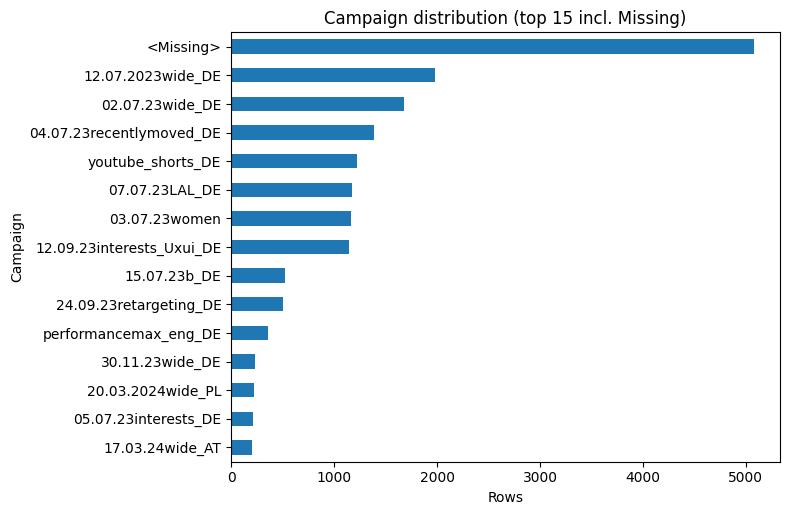

In [24]:
import matplotlib.pyplot as plt

# Anzahl der Top-Kategorien, die angezeigt werden sollen
top_n = 15

# Verteilung der Kampagnen berechnen (Missing als eigene Kategorie)
vc = spend['Campaign'].fillna('<Missing>').value_counts()

# Balkendiagramm der Top-N-Kampagnen erstellen
plt.figure(figsize=(8, max(4, 0.35 * top_n)))
vc.head(top_n).sort_values().plot(kind='barh')

# Diagramm beschriften
plt.title(f'Campaign-Verteilung (Top {top_n} inkl. Missing)')
plt.xlabel('Anzahl der Zeilen')

plt.tight_layout()
plt.show()

Колонки с заполненностью < 80%:
SLA                     0.00
Payment Type            2.30
Months of study         3.89
Level of Deutsch        5.79
City                   11.63
Education Type         15.28
Course duration        16.61
Product                16.63
Initial Amount Paid    19.28
Offer Total Amount     19.38
Content                65.51
Closing Date           67.82
Campaign               74.40
Lost Reason            74.67
dtype: float64

=== Categorical Variables ===
['Lost Reason', 'Campaign', 'Content', 'Payment Type', 'Product', 'Education Type', 'City', 'Level of Deutsch']

=== Numerical Variables ===
['Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount']


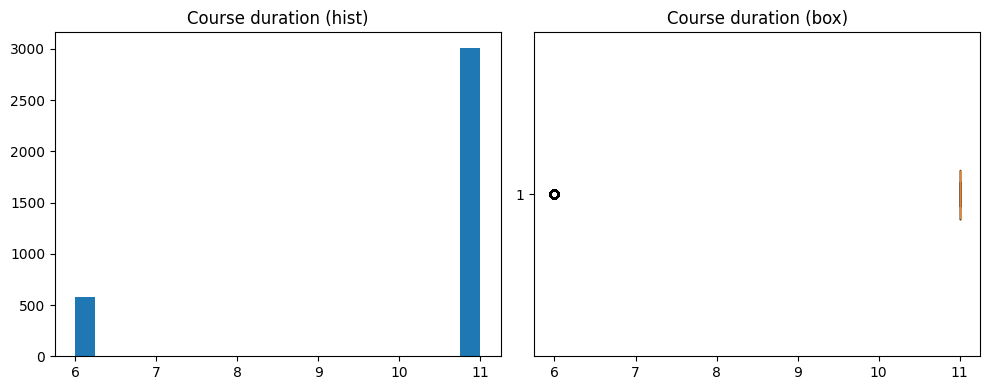

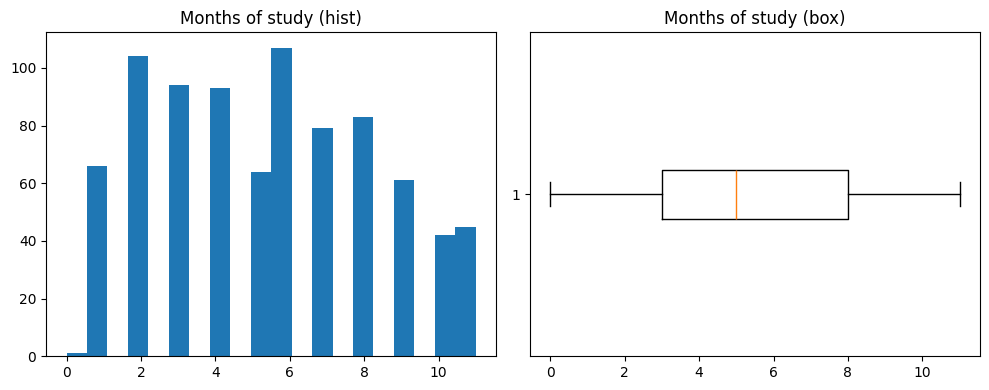

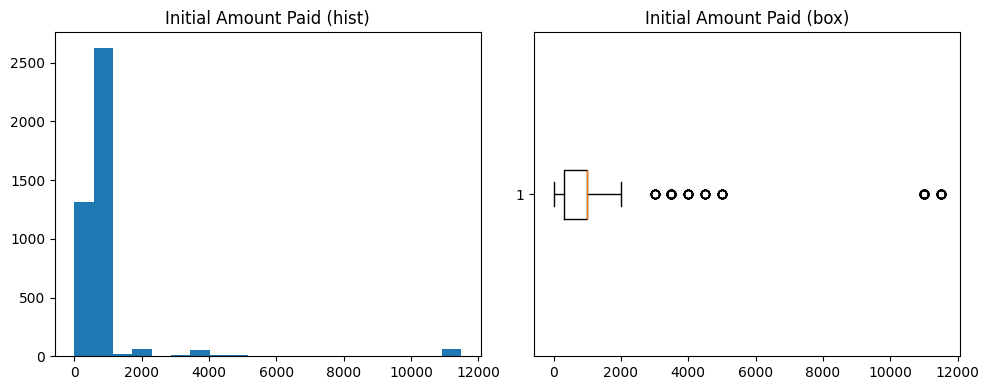

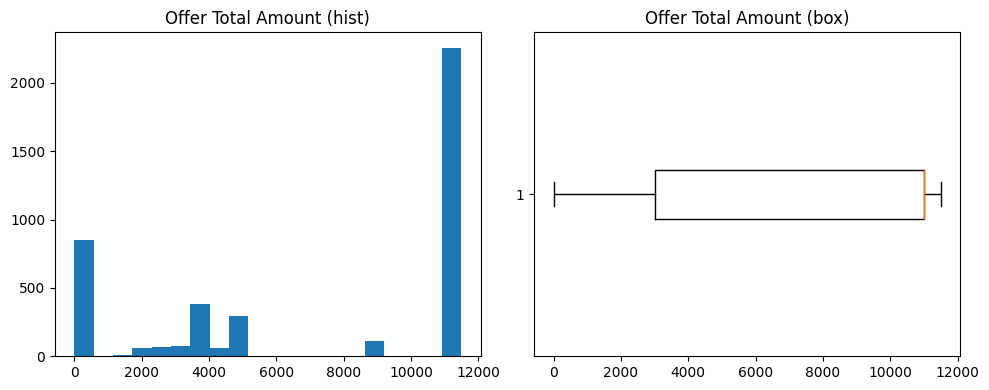

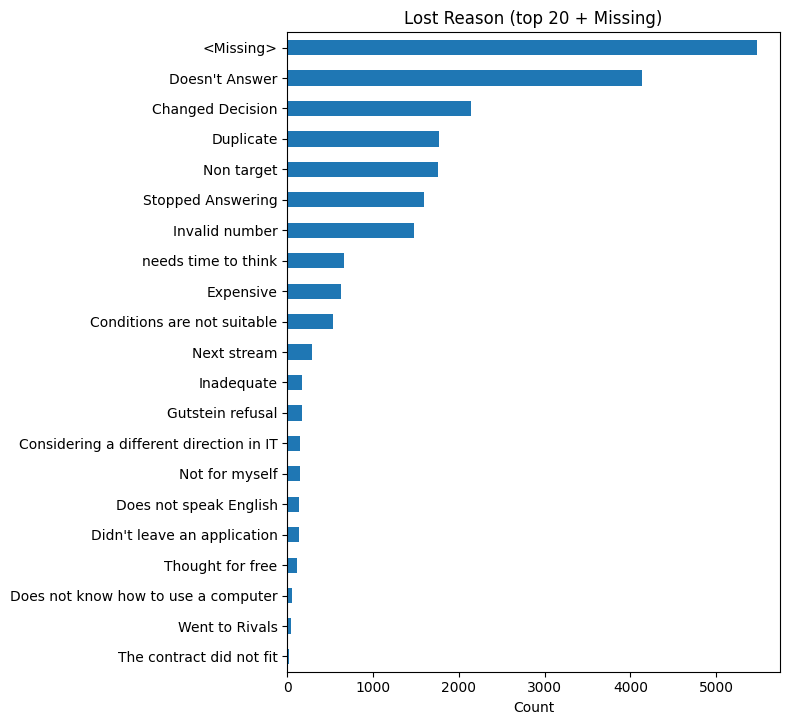

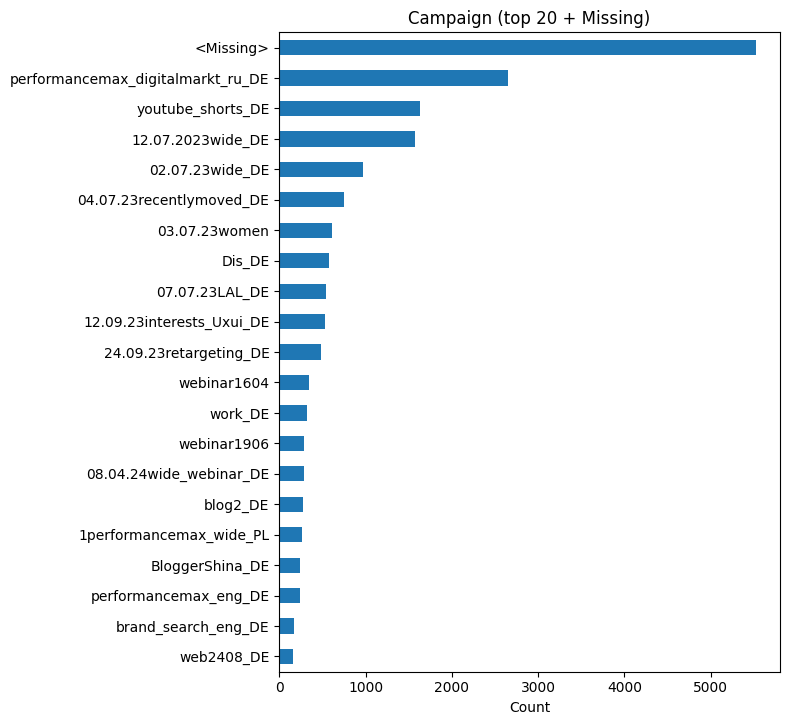

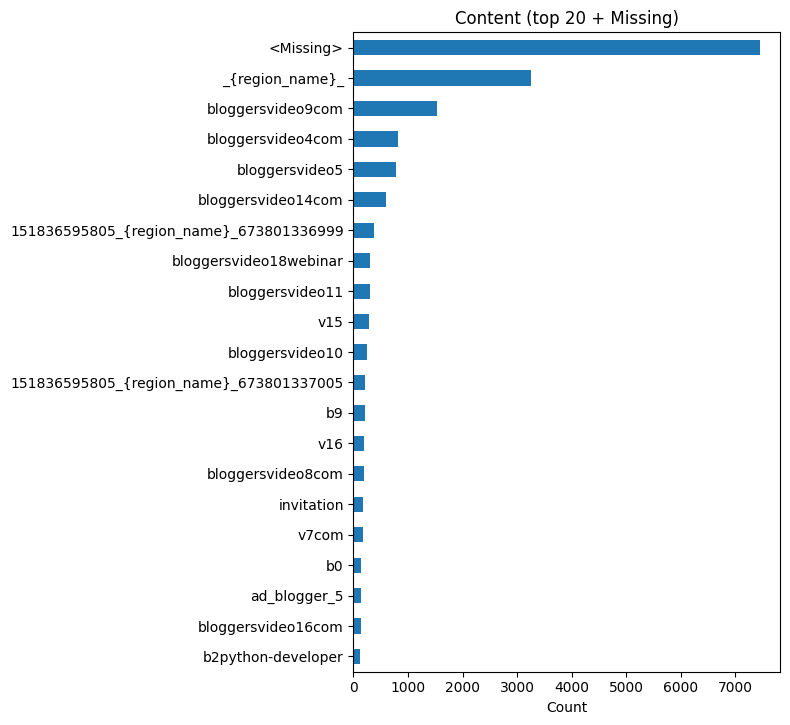

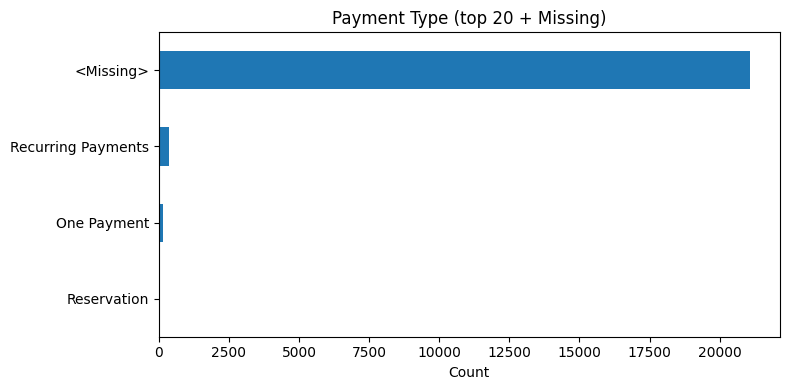

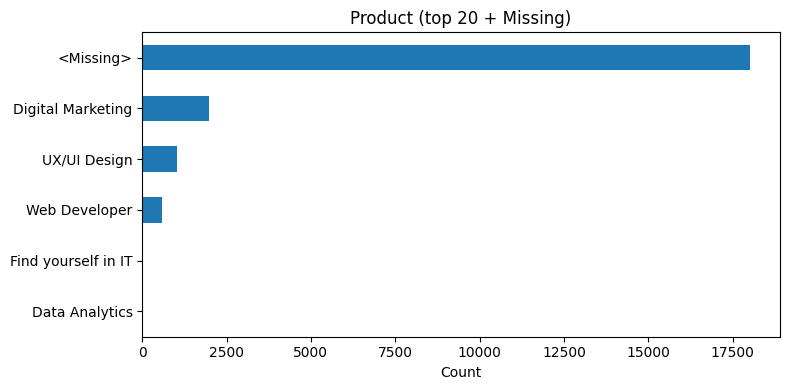

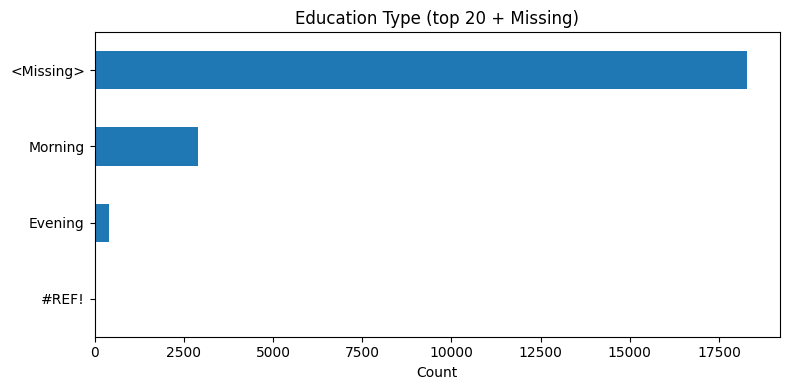

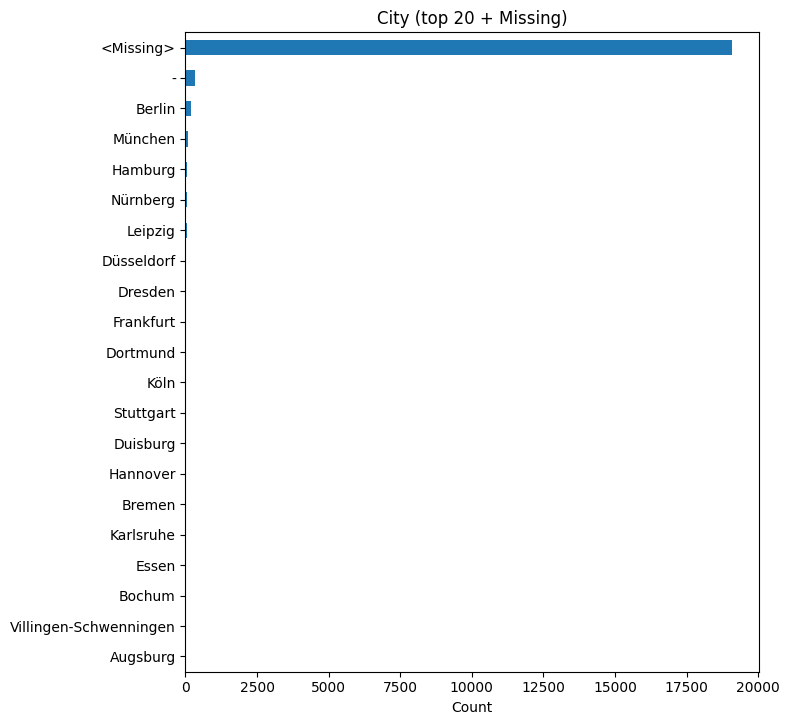

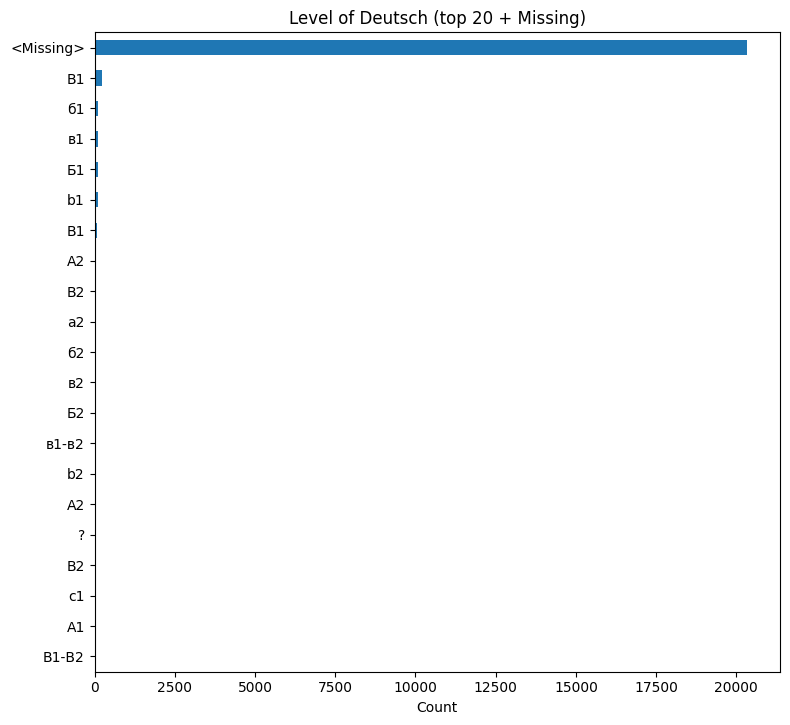

In [25]:
# Для deals
visualize_low_fill_simple(deals, threshold=80)

**# Block 9**
**## Fehlende Werte für Deals auffüllen**

**Strategie zum Auffüllen:**

1. **SLA:** Es wird eine neue Spalte `SLA_days` erstellt, die die Dauer des Deals in Tagen berechnet.
   `0` bedeutet, dass der Deal am selben Tag abgeschlossen wurde.

2. **Level of Deutsch:** Auf Basis dieser Spalte wird eine neue Spalte `Level of Deutsch1` erstellt und auf kategoriale Werte aus der Liste
   (`A1`, `A2`, `B1`, `B2`, `C1`, `C2`) standardisiert.

**Andere Spalten mit fehlenden Werten werden nicht aufgefüllt, damit die Ergebnisse nicht verzerrt werden.**

In [26]:
# ===== DEALS: SLA_days und Level of Deutsch1
#       (die Originalspalten bleiben unverändert) =====

# --- 1) SLA_days: Differenz in Tagen zwischen Created Time und Closing Date ---
# Berechnung nur dort, wo beide Datumswerte vorhanden sind;
# andernfalls bleibt der Wert NaN.
# (0 = am selben Tag abgeschlossen)

created_col = 'Created Time'
closing_col = 'Closing Date'

deals['SLA_days'] = np.nan
mask_dates = deals[created_col].notna() & deals[closing_col].notna()

# Zeitanteile normalisieren (nur das Datum verwenden),
# damit "derselbe Tag" auch bei unterschiedlichen Uhrzeiten als 0 gilt
created_date = deals.loc[mask_dates, created_col].dt.normalize()
closing_date = deals.loc[mask_dates, closing_col].dt.normalize()

deals.loc[mask_dates, 'SLA_days'] = (closing_date - created_date).dt.days
deals['SLA_days'] = deals['SLA_days'].astype('Int64')  # erlaubt NA-Werte

# (optional) Kennzeichen: am selben Tag abgeschlossen
deals['Closed_same_day_flag'] = (deals['SLA_days'] == 0).astype('Int64')


# --- 2) Level of Deutsch1: Standardisierung der Niveaus (A1..C2)
#       + Umwandlung kyrillischer Buchstaben in lateinische ---

level_src = 'Level of Deutsch'
level_dst = 'Level of Deutsch1'

allowed_levels = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
level_rank = {lvl: i for i, lvl in enumerate(allowed_levels)}

# Häufige kyrillische Varianten in lateinische Zeichen umwandeln
# 'в' wird visuell oft anstelle von 'b' verwendet (В ähnelt B)
CYR_TO_LAT = str.maketrans({
    'а': 'a', 'А': 'A',
    'б': 'b', 'Б': 'B',
    'в': 'b', 'В': 'B',
    'с': 'c', 'С': 'C',
})

def normalize_deutsch_level(x):
    if pd.isna(x):
        return pd.NA

    s = str(x).strip().translate(CYR_TO_LAT).upper()

    # Trennzeichen entfernen, um auch Varianten wie
    # "B 1", "B-1", "B.1", "B_1" usw. zu erkennen
    for ch in [" ", "-", "_", "/", "\\", ".", ",", ":", ";", "|"]:
        s = s.replace(ch, "")

    # Alle gefundenen Niveaus sammeln
    found = []
    for lvl in allowed_levels:
        if lvl in s:
            found.append(lvl)

    # Falls nichts gefunden wurde, versuchen wir ein Muster
    # aus Buchstabe+Ziffer zu extrahieren
    if not found:
        import re
        m = re.findall(r'[ABC][12]', s)
        found = [t for t in m if t in level_rank]

    if not found:
        return pd.NA

    # Falls mehrere Niveaus gefunden wurden,
    # wird das höchste Niveau gewählt
    return max(found, key=lambda t: level_rank[t])

deals[level_dst] = deals[level_src].apply(normalize_deutsch_level).astype('category')
deals[level_dst] = deals[level_dst].cat.set_categories(allowed_levels, ordered=True)

# Schnelle Prüfung der Verteilung
print("\n=== Verteilung von Level of Deutsch1 ===")
print(deals[level_dst].value_counts(dropna=False))


=== Level of Deutsch1 distribution ===
Level of Deutsch1
NaN    20401
B1       780
B2       232
A2       119
C1        36
A1        21
C2         5
Name: count, dtype: int64


In [27]:
# Prüfung von SLA_days
print("=== SLA_days: grundlegende Statistiken ===")
print(deals['SLA_days'].describe())

=== SLA_days: basic stats ===
count      14645.0
mean     14.882622
std      31.797587
min         -357.0
25%            1.0
50%            3.0
75%           12.0
max          335.0
Name: SLA_days, dtype: Float64


In [28]:
# Prüfung auf negative SLA-Werte
neg_sla = deals[deals['SLA_days'] < 0]

print(f"Zeilen mit negativem SLA_days: {len(neg_sla)}")

# Falls vorhanden, einige Beispiele anzeigen
if not neg_sla.empty:
    print(neg_sla[['Created Time', 'Closing Date', 'SLA_days']].head())

Negative SLA_days rows: 44
            Created Time Closing Date  SLA_days
454  2024-06-16 00:06:00   2024-06-11        -5
2083 2024-05-25 21:29:00   2024-05-22        -3
2787 2024-05-12 11:19:00   2024-05-07        -5
3019 2024-05-08 15:31:00   2024-05-07        -1
3022 2024-05-08 14:48:00   2024-04-17       -21


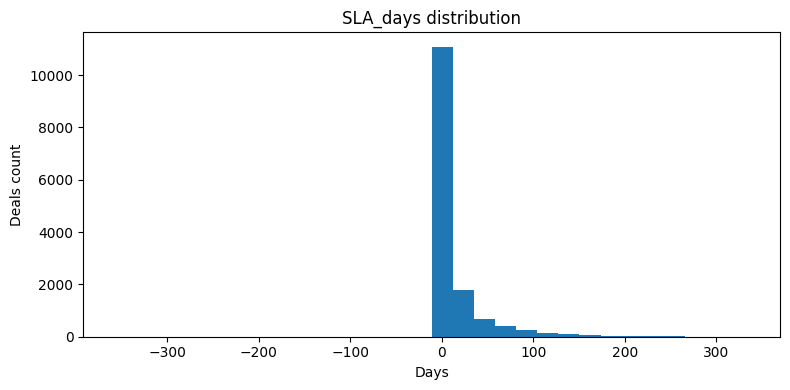

In [29]:
import matplotlib.pyplot as plt

# SLA_days ohne fehlende Werte auswählen
sla_non_na = deals['SLA_days'].dropna()

# Histogramm der SLA-Verteilung erstellen
plt.figure(figsize=(8, 4))
plt.hist(sla_non_na, bins=30)

# Diagramm beschriften
plt.title('Verteilung von SLA_days')
plt.xlabel('Tage')
plt.ylabel('Anzahl der Deals')

plt.tight_layout()
plt.show()

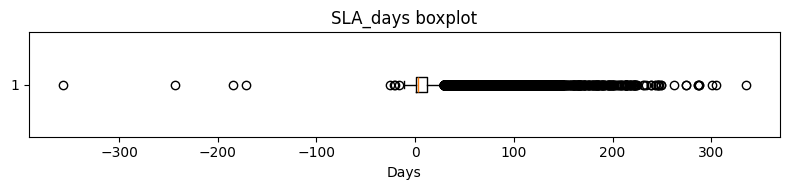

In [30]:
# Boxplot für SLA_days erstellen
plt.figure(figsize=(8, 2))
plt.boxplot(sla_non_na, vert=False)

# Diagramm beschriften
plt.title('SLA_days Boxplot')
plt.xlabel('Tage')

plt.tight_layout()
plt.show()

In [31]:
print("=== SLA_days quantiles ===")
print(deals['SLA_days'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

=== SLA_days quantiles ===
0.25      1.0
0.50      3.0
0.75     12.0
0.90     43.0
0.95     78.8
0.99    164.0
Name: SLA_days, dtype: Float64


In [32]:
same_day = (deals['SLA_days'] == 0).sum()
total_with_sla = deals['SLA_days'].notna().sum()

print(f"Closed same day: {same_day} ({same_day / total_with_sla * 100:.2f}%)")

Closed same day: 3268 (22.31%)


In [33]:
sla_by_stage = (
    deals
    .dropna(subset=['SLA_days', 'Stage'])
    .groupby('Stage')['SLA_days']
    .median()
    .sort_values()
)

print("=== Median SLA_days by Stage ===")
print(sla_by_stage)

=== Median SLA_days by Stage ===
Stage
Registered on Webinar         2.0
Waiting For Payment           2.0
Qualificated                  2.0
Lost                          3.0
Call Delayed                  4.0
Need to Call - Sales          4.0
Test Sent                     8.5
Payment Done                 17.0
Free Education               <NA>
Need To Call                 <NA>
Need a consultation          <NA>
New Lead                     <NA>
Registered on Offline Day    <NA>
Name: SLA_days, dtype: Float64


C:\Users\Acer\AppData\Local\Temp\ipykernel_11732\2082392113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Stage')['SLA_days']


In [34]:
# Negative SLA_days → auf NaN setzen (NUR für negative Werte)
# Negative SLA-Werte sind ein Datenfehler, kein realer Business-Fakt

# Flag für negative SLA-Werte erstellen
deals['SLA_negative_flag'] = (deals['SLA_days'] < 0).astype('Int64')

# Negative Werte durch NA ersetzen
deals.loc[deals['SLA_days'] < 0, 'SLA_days'] = pd.NA

# Datentyp erneut als Int64 setzen (unterstützt NA-Werte)
deals['SLA_days'] = deals['SLA_days'].astype('Int64')

In [35]:
# Ausreißeranalyse vorbereiten
# Nur Deals mit gültigem SLA_days (ohne NaN) auswählen
deals_valid = deals[deals['SLA_days'].notna()].copy()

In [36]:
# Grenzen für Ausreißer berechnen (IQR-Methode)

Q1 = deals_valid['SLA_days'].quantile(0.25)  # 1. Quartil
Q3 = deals_valid['SLA_days'].quantile(0.75)  # 3. Quartil
IQR = Q3 - Q1                                # Interquartilsabstand

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [37]:
# Analytischen Datenausschnitt erstellen (Originaldaten bleiben unverändert)

deals_sla_typical = deals_valid[
    (deals_valid['SLA_days'] >= lower_bound) &
    (deals_valid['SLA_days'] <= upper_bound)
].copy()

print("=== Typische SLA-Werte (IQR-gefiltert) ===")
print(deals_sla_typical['SLA_days'].describe())

=== SLA typical (IQR-filtered) ===
count     12537.0
mean     4.815825
std      6.144218
min           0.0
25%           0.0
50%           2.0
75%           7.0
max          28.0
Name: SLA_days, dtype: Float64


In [38]:
def visualize_two_cols(
    df: pd.DataFrame,
    num_col: str = "SLA_days",
    cat_col: str = "Level of Deutsch1",
    top_n: int = 20
):
    if df is None or len(df) == 0:
        print("Der DataFrame ist leer — es gibt nichts zu visualisieren.")
        return

    # ===== NUMERISCHE SPALTE =====
    if num_col in df.columns:
        s = pd.to_numeric(df[num_col], errors="coerce")
        s = s[s.notna()]   # NaN-Werte werden einfach ausgeschlossen

        if len(s) > 0:
            plt.figure(figsize=(8, 4))
            plt.hist(s, bins=30)
            plt.title(f"Verteilung von {num_col}")
            plt.xlabel(num_col)
            plt.ylabel("Anzahl")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 2))
            plt.boxplot(s, vert=False)
            plt.title(f"Boxplot von {num_col}")
            plt.xlabel(num_col)
            plt.tight_layout()
            plt.show()
        else:
            print(f"[{num_col}] Keine Daten für die Visualisierung vorhanden.")

    # ===== KATEGORIALE SPALTE =====
    if cat_col in df.columns:
        # WICHTIG: Es werden nur nicht-leere Werte verwendet
        cat_series = df[cat_col]
        cat_series = cat_series[cat_series.notna()]

        if len(cat_series) == 0:
            print(f"[{cat_col}] Keine Daten für die Visualisierung vorhanden.")
            return

        vc = cat_series.value_counts().head(top_n)

        plt.figure(figsize=(8, max(4, 0.35 * len(vc))))
        vc.sort_values().plot(kind="barh")
        plt.title(f"{cat_col} (Top {top_n}, ohne Missing)")
        plt.xlabel("Anzahl")
        plt.tight_layout()
        plt.show()

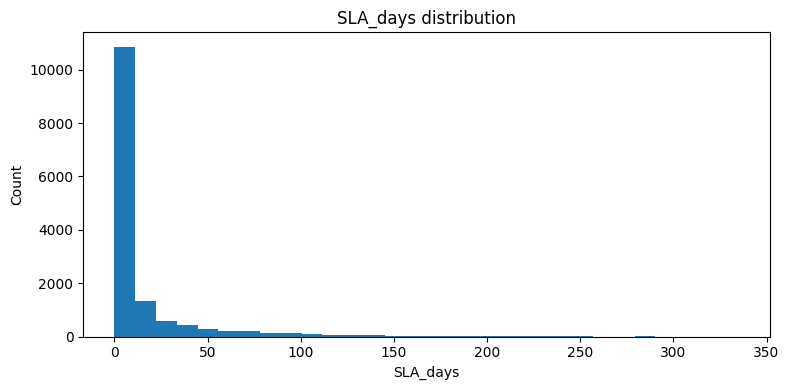

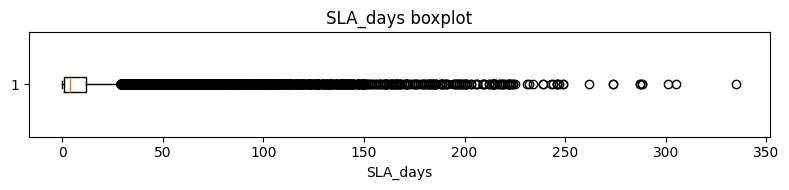

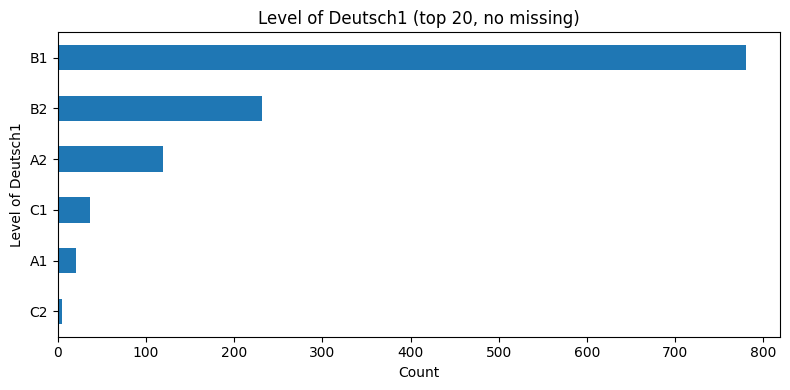

In [39]:
visualize_two_cols(
    deals,
    num_col="SLA_days",
    cat_col="Level of Deutsch1",
    top_n=20
)

In [40]:
cat_cols = [
    "Quality",
    "Stage",
    "Page",
    "Campaign",
    "Content",
    "Source",
    "Lost Reason",
    "Product",
    "Education Type",
    "City",
    "Level of Deutsch",
    "Level of Deutsch1",
    "Closed_same_day_flag",
    "SLA_negative_flag"
]

In [41]:
num_cols = [
    "Course duration",
    "Months of study",
    "Initial Amount Paid",
    "Offer Total Amount",
    "SLA_days"
]

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import math

def visualize_selected_deals_columns(
    df: pd.DataFrame,
    num_cols: list,
    cat_cols: list,
    max_categories: int = 10,
    plots_per_row: int = 3
):
    cols = []

    for c in cat_cols + num_cols:
        if c in df.columns:
            cols.append(c)

    n_cols = plots_per_row
    n_rows = math.ceil(len(cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 3 * n_rows))
    plot_idx = 1

    for col in cols:
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        plot_idx += 1

        s = df[col]

        # ===== NUMERISCHE SPALTEN =====
        if col in num_cols:
            s_num = pd.to_numeric(s, errors="coerce").dropna()

            if len(s_num) > 0:
                ax.hist(s_num, bins=20)
                ax.set_title(col)
            else:
                ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center")
                ax.set_title(col)

        # ===== KATEGORIALE SPALTEN =====
        else:
            s_cat = s[s.notna()]

            if len(s_cat) > 0:
                vc = s_cat.value_counts().head(max_categories)
                vc.sort_values().plot(kind="barh", ax=ax)
                ax.set_title(col)
            else:
                ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center")
                ax.set_title(col)

    plt.tight_layout()
    plt.show()

In [51]:
# Visualisierung der Verteilungen für Deals starten
visualize_deals_distributions(
    deals,
    max_categories=10,   # Top-10 Kategorien anzeigen
    plots_per_row=3      # Anzahl der Diagramme pro Zeile
)

NameError: name 'visualize_deals_distributions' is not defined

In [52]:
# Verteilungen für numerische Spend-Spalten analysieren
num_cols_spend = [
    "Impressions",
    "Clicks",
    "Spend"
]

In [53]:
cat_cols_spend = [
    "Source",
    "Campaign",
]

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import math

def visualize_selected_spend_columns(
    df: pd.DataFrame,
    num_cols: list,
    cat_cols: list,
    max_categories: int = 10,
    plots_per_row: int = 3
):
    cols = [c for c in (cat_cols + num_cols) if c in df.columns]

    n_cols = plots_per_row
    n_rows = math.ceil(len(cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 3 * n_rows))
    plot_idx = 1

    for col in cols:
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        plot_idx += 1

        s = df[col]

        # ===== NUMERISCHE SPALTEN =====
        if col in num_cols:
            s_num = pd.to_numeric(s, errors="coerce").dropna()

            if len(s_num) > 0:
                ax.hist(s_num, bins=25)
                ax.set_title(col)
            else:
                ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center")
                ax.set_title(col)

        # ===== KATEGORIALE SPALTEN =====
        else:
            s_cat = s[s.notna()]

            if len(s_cat) > 0:
                vc = s_cat.value_counts().head(max_categories)
                vc.sort_values().plot(kind="barh", ax=ax)
                ax.set_title(col)
            else:
                ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center")
                ax.set_title(col)

    plt.tight_layout()
    plt.show()

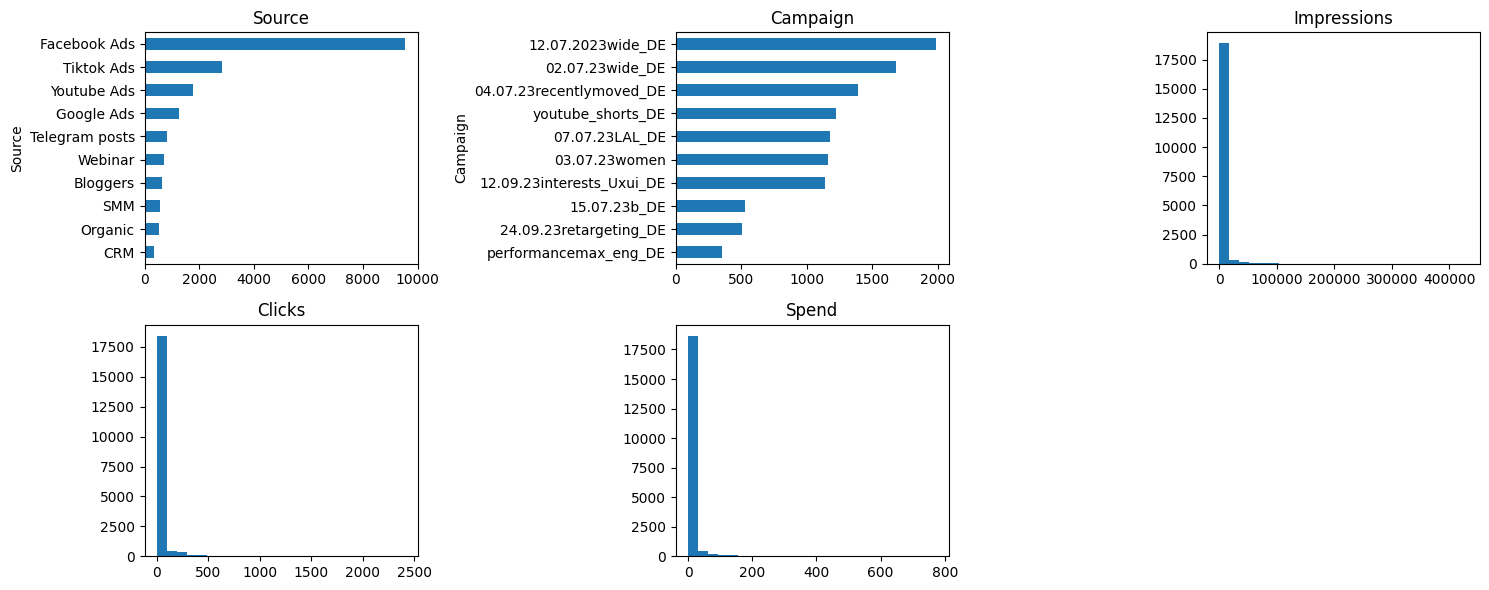

In [55]:
visualize_selected_spend_columns(
    spend,
    num_cols=num_cols_spend,
    cat_cols=cat_cols_spend,
    max_categories=10,
    plots_per_row=3
)

In [57]:
deals = deals.drop(columns=['SLA'], errors='ignore')

In [58]:
from openpyxl import load_workbook
from openpyxl.styles import numbers

def save_xlsx_with_text_cols(df, path, text_cols):
    df.to_excel(path, index=False, engine="openpyxl")
    wb = load_workbook(path)
    ws = wb.active

    headers = [cell.value for cell in ws[1]]
    col_idx = {h: i+1 for i, h in enumerate(headers) if h in text_cols}

    for _, idx in col_idx.items():
        for row in range(2, ws.max_row + 1):
            cell = ws.cell(row=row, column=idx)
            cell.number_format = numbers.FORMAT_TEXT
            if cell.value is not None:
                cell.value = str(cell.value)

    wb.save(path)

output_path = r"C:\Users\Acer\Projekt\Output"

save_xlsx_with_text_cols(spend,    f"{output_path}\\spend_cleaned062.xlsx",    [])
save_xlsx_with_text_cols(deals,    f"{output_path}\\deals_cleaned062.xlsx",    ["Id", "Contact Name"])
save_xlsx_with_text_cols(calls,    f"{output_path}\\calls_cleaned062.xlsx",    ["Id", "CONTACTID"])
save_xlsx_with_text_cols(contacts, f"{output_path}\\contacts_cleaned062.xlsx", ["Id"])